# Noise reduction under a hearing-aid latency budget

A hearing aid has to clean the speech it amplifies, but it cannot wait: in an open fitting the direct
sound leaks into the ear canal and adds to the processed one, and if the processed sound is more than
~10 ms late the sum sounds metallic (a comb filter). Textbook noise reduction uses 32 ms frames. This
notebook builds the classical single-microphone pipeline frame by frame, exactly as it would run live,
and measures **how much quality each millisecond of latency buys**.

Everything is in [`audiolab.enhancement`](../src/audiolab/enhancement.py):

1. **STFT analysis and synthesis** with weighted overlap-add (WOLA): every hop of R samples, the latest
   N samples are windowed, transformed, multiplied by a gain per frequency bin, transformed back and
   overlap-added. The latency is the frame length N.
2. **Noise estimation** while the person talks: minima-controlled recursive averaging (MCRA, Cohen 2002)
   and the speech-presence-probability estimator (SPP, Gerkmann and Hendriks 2012).
3. **Gain rules**: power spectral subtraction, Wiener, Wiener with the decision-directed a priori SNR
   (Ephraim and Malah 1984), and its two-step refinement (Plapous et al. 2006), all with a gain floor.

**Test set.** VoiceBank+DEMAND (Valentini-Botinhao et al., 2016, CC BY 4.0): 824 sentences from 2
speakers mixed with real noise recordings at 2.5 to 17.5 dB SNR, the standard benchmark for speech
enhancement. Resampled from 48 to 16 kHz. Because the clean speech is known, the exact noise is too
(noisy − clean), which makes two things possible: measuring the noise estimators directly, and an
**oracle** gain computed from the true speech and noise of every frame, the upper bound of any gain
per bin at that frame length.

**Metrics.** SI-SDR (scale-invariant signal-to-distortion ratio, dB: how close the waveform is to the
clean one), STOI (short-time objective intelligibility, 0-1: predicts the fraction of words understood)
and PESQ (perceptual quality, ITU-T P.862.2, computed in Colab with
[`denoising_pesq.ipynb`](denoising_pesq.ipynb) because the package needs a C compiler).
`scripts/evaluate_denoising.py` runs every method on all 824 sentences and saves one row per sentence
and configuration.

In [1]:
%load_ext autoreload
%autoreload 2

import time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import soundfile as sf
from scipy.signal import resample_poly

from audiolab.enhancement import (MCRA, NoiseReducer, OracleWiener, SPPNoise, Wola, frame_sizes,
                                  process_signal, si_sdr, stft_frames)

DATA = Path("../data")
VB = DATA / "voicebank"
FIGURES = Path("../docs/figures")
SR = 16000
FRAMES_MS = (4, 8, 16, 32)
BLUE, ORANGE, GREEN, YELLOW, PINK = "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"
TEXT, MUTED = "#0b0b0b", "#52514e"


def load_pair(name):
    # Clean and noisy versions of a test sentence, at 16 kHz
    clean, noisy = (resample_poly(sf.read(VB / f"{kind}_testset_wav" / f"{name}.wav")[0], 1, 3)
                    for kind in ("clean", "noisy"))
    return clean, noisy

## 1. The framework: perfect reconstruction, and latency = frame length

With a square-root Hann window for both analysis and synthesis, their product is a Hann window, and Hann
windows shifted by half a frame add up to exactly one. So with a gain of 1 the output is the input,
delayed. The delay is N − R samples inside the algorithm, plus the R samples the device waits to collect
a block: **N in total, whatever the hop**. The hop only sets how many frames per second must be
computed.

In [2]:
x = np.random.default_rng(0).standard_normal(SR * 5)
rows = []
for ms in FRAMES_MS:
    n_fft, hop = frame_sizes(ms, SR)
    wola = Wola(n_fft, hop)
    start = time.perf_counter()
    y = process_signal(x, wola)
    per_frame = (time.perf_counter() - start) / (len(x) / hop)
    rows.append({"frame (ms)": ms, "N": n_fft, "hop R": hop, "latency (ms)": 1000 * n_fft / SR,
                 "bin spacing (Hz)": SR / n_fft, "max |error|": np.max(np.abs(y - x)),
                 "time per frame (µs)": 1e6 * per_frame, "% of real time": 100 * per_frame / (hop / SR)})
pd.DataFrame(rows).set_index("frame (ms)").style.format(
    {"latency (ms)": "{:.0f}", "bin spacing (Hz)": "{:.1f}", "max |error|": "{:.1e}",
     "time per frame (µs)": "{:.0f}", "% of real time": "{:.2f}"})

,N,hop R,latency (ms),bin spacing (Hz),max |error|,time per frame (µs),% of real time
frame (ms),,,,,,,
4,64,32,4,250.0,1.8e-15,44,2.21
8,128,64,8,125.0,1.8e-15,48,1.21
16,256,128,16,62.5,2.2e-15,50,0.63
32,512,256,32,31.2,1.8e-15,63,0.39


The reconstruction error is at the level of floating-point rounding. The cost of a frame barely depends
on N (Python overhead dominates over the FFT), so in Python shorter frames cost more per second only
because there are more of them; on a hearing-aid chip the budget would be far tighter.

The price of a short frame is frequency resolution: the bins are fs/N apart. Voiced speech has harmonics
every 100-250 Hz (its pitch). With 32 ms frames (31 Hz bins) the gaps between harmonics are visible and
can be attenuated; with 4 ms frames (250 Hz bins) every bin mixes harmonics and gaps.

## 2. Estimating the noise while the person talks

The gain needs the noise power in every bin, λ(k), but the microphone never delivers the noise alone.
Both estimators rely on the noise changing slower than speech. Since the test set includes the clean
speech, the true noise is known and the estimates can be checked directly: below, the median error
of each estimator (in dB) against the true noise power smoothed over ±0.5 s, on 1 of every 8 sentences.

In [3]:
names = sorted(p.stem for p in (VB / "clean_testset_wav").glob("*.wav"))
subset = names[::8]
pairs = {name: load_pair(name) for name in subset}

def noise_error_db(Estimator, ms):
    n_fft, hop = frame_sizes(ms, SR)
    errors = []
    for clean, noisy in pairs.values():
        true = np.abs(stft_frames(noisy - clean, n_fft, hop)) ** 2
        k = int(0.5 * SR / hop)
        true = np.array([true[max(0, i - k):i + k].mean(axis=0) for i in range(len(true))])
        est = Estimator(n_fft // 2 + 1, hop / SR)
        estimate = np.array([est.update(np.abs(X) ** 2) for X in stft_frames(noisy, n_fft, hop)])
        errors.append(np.median(10 * np.log10(estimate / (true + 1e-20))))
    return np.median(errors)

pd.DataFrame({name: [noise_error_db(E, ms) for ms in FRAMES_MS] for name, E in (("MCRA", MCRA), ("SPP", SPPNoise))},
             index=pd.Index(FRAMES_MS, name="frame (ms)")).style.format("{:+.1f} dB")

,MCRA,SPP
frame (ms),,
4,+2.9 dB,-0.3 dB
8,+2.6 dB,-0.5 dB
16,+2.1 dB,-0.8 dB
32,+1.2 dB,-0.9 dB


MCRA overestimates the noise, more with short frames, and an overestimated noise means a gain that also
cuts speech. The reason shows up with a test tone that switches on after one second of noise: MCRA
decides that speech is present when the smoothed power exceeds 5 times its recent minimum, but the
smoothing reacts a few frames late, and meanwhile the noise estimate takes in the start of the sound.
SPP compares each new frame with the previous noise estimate through a probability of speech presence,
so it reacts in the same frame. (A sound that stays perfectly steady for more than ~0.65 s is eventually
accepted as noise by SPP too; that is on purpose, so that a real rise of the noise is followed.)

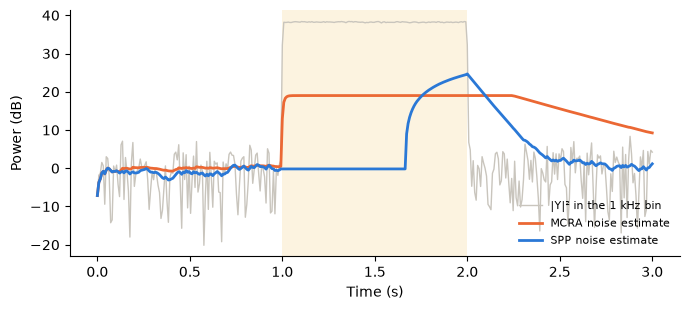

In [4]:
n_fft, hop = frame_sizes(16, SR)
rng = np.random.default_rng(3)
x = 0.1 * rng.standard_normal(SR * 3)
x[SR:2 * SR] += np.sin(2 * np.pi * 1000 * np.arange(SR) / SR)
k = int(1000 * n_fft / SR)
power = np.abs(stft_frames(x, n_fft, hop)) ** 2
t = np.arange(len(power)) * hop / SR

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(t, 10 * np.log10(power[:, k]), color="#c9c5bd", linewidth=1, label="|Y|² in the 1 kHz bin")
for name, E, color in (("MCRA", MCRA, ORANGE), ("SPP", SPPNoise, BLUE)):
    est = E(n_fft // 2 + 1, hop / SR)
    ax.plot(t, 10 * np.log10([est.update(p)[k] for p in power]), color=color, linewidth=2, label=f"{name} noise estimate")
ax.axvspan(1, 2, color=YELLOW, alpha=0.12, linewidth=0)
ax.annotate("1 kHz tone on", (1.02, 52), fontsize=8, color=MUTED)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Power (dB)")
ax.legend(frameon=False, fontsize=8, loc="lower right")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 3. What the gain does to one sentence

The decision-directed rule estimates the a priori SNR ξ (clean speech over noise) by mixing the cleaned
power of the previous frame with the current measurement, so ξ cannot jump with every random peak of
the noise. Without it (plain Wiener, ξ = γ − 1), isolated noise peaks survive in random bins and frames:
the twinkling "musical noise", visible as scattered dots in the pauses. All use SPP and a −15 dB floor.
The sentence is a typical one: 5 dB input SNR, and an improvement with the 32 ms decision-directed rule
close to the median over the test set (6.5 dB vs. 6.0 dB).

p257_322: input SNR 5.1 dB


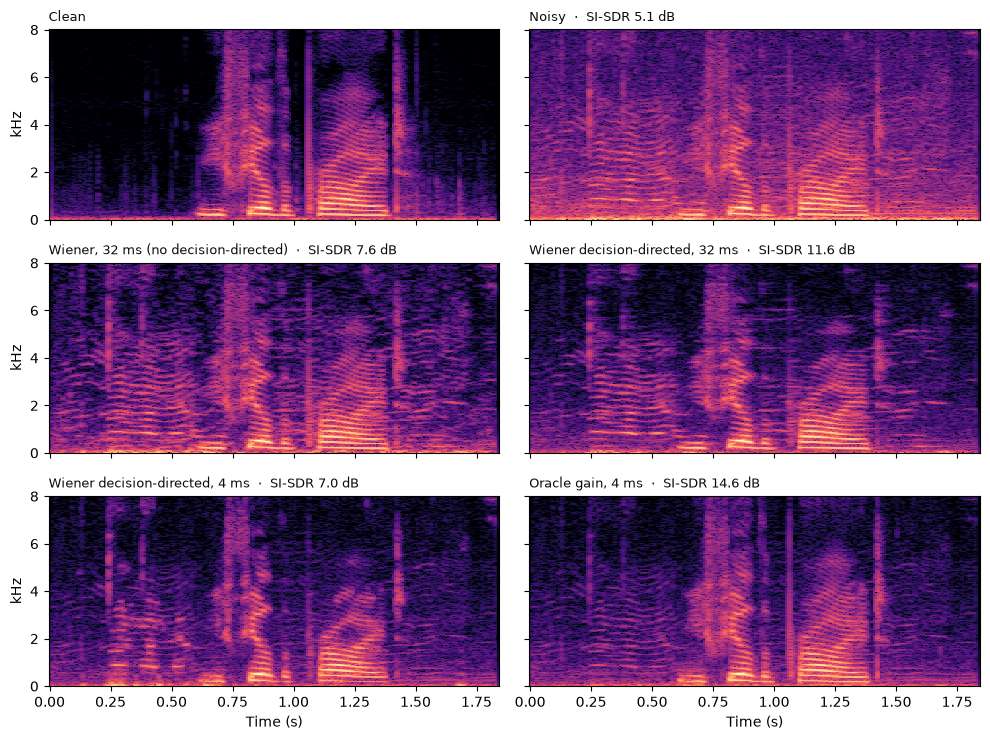

In [5]:
name = "p257_322"
clean, noisy = load_pair(name)
print(f"{name}: input SNR {10 * np.log10(np.sum(clean ** 2) / np.sum((noisy - clean) ** 2)):.1f} dB")

def enhance(rule, ms, signal=noisy):
    n_fft, hop = frame_sizes(ms, SR)
    if rule == "oracle":
        fn = OracleWiener(clean, noisy - clean, n_fft, hop)
    else:
        fn = NoiseReducer(SPPNoise(n_fft // 2 + 1, hop / SR), hop / SR, rule)
    return process_signal(signal, Wola(n_fft, hop), fn)

panels = [("Clean", clean), ("Noisy", noisy), ("Wiener, 32 ms (no decision-directed)", enhance("wiener", 32)),
          ("Wiener decision-directed, 32 ms", enhance("wiener_dd", 32)),
          ("Wiener decision-directed, 4 ms", enhance("wiener_dd", 4)), ("Oracle gain, 4 ms", enhance("oracle", 4))]
fig, axes = plt.subplots(3, 2, figsize=(10, 7.5), sharex=True, sharey=True)
for ax, (title, y) in zip(axes.flat, panels):
    S = np.abs(stft_frames(y, 512, 128)) ** 2                  # same 32 ms analysis for all panels
    t_axis = np.arange(len(S)) * 128 / SR
    ax.pcolormesh(t_axis, np.arange(S.shape[1]) * SR / 512 / 1000, 10 * np.log10(S.T + 1e-10),
                  vmin=-60, vmax=30, cmap="magma", shading="auto", rasterized=True)
    sdr = "" if y is clean else f"  ·  SI-SDR {si_sdr(clean, y):.1f} dB"
    ax.set_title(title + sdr, fontsize=9, color=TEXT, loc="left")
for ax in axes[:, 0]:
    ax.set_ylabel("kHz")
for ax in axes[-1]:
    ax.set_xlabel("Time (s)")
plt.tight_layout()
plt.savefig(FIGURES / "denoising_spectrograms.png", dpi=150)
plt.show()

## 4. Results on the 824 test sentences

Means over all sentences. The noisy input does not depend on the frame length. `dd` = Wiener with the
decision-directed rule; all methods use a −15 dB gain floor unless stated.

In [6]:
res = pd.read_csv(DATA / "results" / "denoising.csv")
KEYS = ["file", "frame_ms", "overlap", "rule", "noise", "floor_db"]
res = res.merge(pd.read_csv(DATA / "results" / "denoising_pesq.csv").drop(columns="input_snr"), on=KEYS)
METRICS = (("si_sdr", "SI-SDR (dB)", "{:.2f}"), ("stoi", "STOI", "{:.3f}"), ("pesq", "PESQ", "{:.2f}"))
noisy = res[res.rule == "noisy"]
label = {("subtraction", "spp", 2): "subtraction (SPP)", ("wiener", "spp", 2): "Wiener (SPP)",
         ("wiener_dd", "mcra", 2): "dd (MCRA)", ("wiener_dd", "spp", 2): "dd (SPP)",
         ("wiener_tsnr", "spp", 2): "two-step (SPP)", ("wiener_dd", "spp", 4): "dd (SPP), 75% overlap",
         ("oracle", "-", 2): "oracle"}
main = res[(res.floor_db == -15) & (res.rule != "noisy")].copy()
main["method"] = [label[k] for k in zip(main.rule, main.noise, main.overlap)]
order = list(label.values())

for metric, title, fmt in METRICS:
    table = main.pivot_table(index="method", columns="frame_ms", values=metric).reindex(order)
    table.loc["noisy (no processing)"] = noisy[metric].mean()
    display(table.style.format(fmt).set_caption(title))

frame_ms,4,8,16,32
method,,,,
subtraction (SPP),9.60,9.86,10.41,10.99
Wiener (SPP),10.01,10.42,11.25,12.02
dd (MCRA),7.20,9.06,11.03,12.73
dd (SPP),10.03,11.95,14.05,14.73
two-step (SPP),10.51,12.06,13.87,14.52
"dd (SPP), 75% overlap",10.11,11.87,13.98,14.91
oracle,15.30,16.74,18.11,18.89
noisy (no processing),8.45,8.45,8.45,8.45


frame_ms,4,8,16,32
method,,,,
subtraction (SPP),0.915,0.916,0.920,0.922
Wiener (SPP),0.913,0.915,0.919,0.922
dd (MCRA),0.882,0.885,0.886,0.893
dd (SPP),0.894,0.902,0.905,0.910
two-step (SPP),0.900,0.908,0.912,0.916
"dd (SPP), 75% overlap",0.899,0.907,0.909,0.911
oracle,0.946,0.952,0.956,0.958
noisy (no processing),0.921,0.921,0.921,0.921


frame_ms,4,8,16,32
method,,,,
subtraction (SPP),1.97,2.04,2.13,2.15
Wiener (SPP),2.01,2.10,2.20,2.23
dd (MCRA),2.14,2.26,2.27,2.34
dd (SPP),2.20,2.41,2.47,2.45
two-step (SPP),2.19,2.36,2.44,2.42
"dd (SPP), 75% overlap",2.20,2.38,2.49,2.47
oracle,2.58,2.78,2.98,3.05
noisy (no processing),1.97,1.97,1.97,1.97


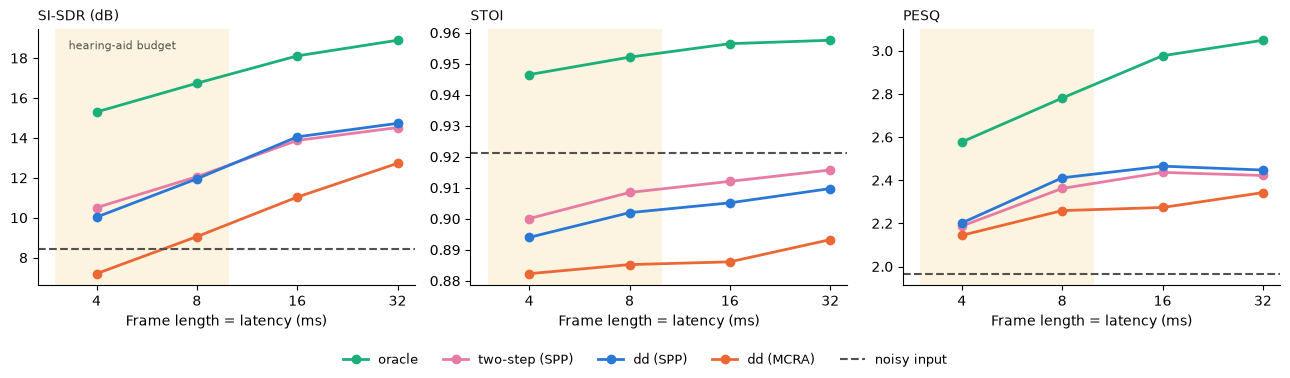

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
series = [("oracle", GREEN), ("two-step (SPP)", PINK), ("dd (SPP)", BLUE), ("dd (MCRA)", ORANGE)]
for ax, (metric, title, _) in zip(axes, METRICS):
    means = main.groupby(["method", "frame_ms"])[metric].mean()
    for method, color in series:
        ax.plot(FRAMES_MS, means[method].reindex(FRAMES_MS), color=color, linewidth=2, marker="o", label=method)
    ax.axhline(noisy[metric].mean(), color=MUTED, linewidth=1.5, linestyle="--", label="noisy input")
    ax.axvspan(3, 10, color=YELLOW, alpha=0.12, linewidth=0)
    ax.set_xscale("log", base=2)
    ax.set_xticks(FRAMES_MS, [f"{ms}" for ms in FRAMES_MS])
    ax.set_xlabel("Frame length = latency (ms)")
    ax.set_title(title, fontsize=10, color=TEXT, loc="left")
    ax.spines[["top", "right"]].set_visible(False)
axes[0].annotate("hearing-aid budget", (3.3, axes[0].get_ylim()[1] * 0.97), fontsize=8, color=MUTED, va="top")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, frameon=False, fontsize=9, loc="lower center", ncol=5)
plt.tight_layout(rect=(0, 0.08, 1, 1))
plt.savefig(FIGURES / "denoising_latency.png", dpi=150)
plt.show()

**By input SNR.** The test set mixes four nominal SNRs. Improvement over the noisy input for the
decision-directed rule with SPP, grouped by the measured SNR of each sentence (the nominal SNRs use the
active speech level, so the measured ones are a little lower):

In [8]:
dd = main[main.method == "dd (SPP)"].merge(noisy[["file", "si_sdr", "stoi"]], on="file", suffixes=("", "_noisy"))
orc = main[main.method == "oracle"].merge(noisy[["file", "stoi"]], on="file", suffixes=("", "_noisy"))
bins = pd.cut(dd.input_snr, [-10, 4, 9, 14, 40], labels=["< 4 dB", "4-9 dB", "9-14 dB", "> 14 dB"])
summary = pd.DataFrame({
    "ΔSI-SDR (dB)": (dd.si_sdr - dd.si_sdr_noisy).groupby([bins, dd.frame_ms], observed=True).mean(),
    "ΔSTOI": (dd.stoi - dd.stoi_noisy).groupby([bins, dd.frame_ms], observed=True).mean(),
    "ΔSTOI oracle": (orc.stoi - orc.stoi_noisy).groupby(
        [pd.cut(orc.input_snr, [-10, 4, 9, 14, 40], labels=bins.cat.categories), orc.frame_ms], observed=True).mean(),
}).unstack("frame_ms")
summary.style.format("{:+.3f}")

**How much to suppress: the gain floor.** The floor is the maximum attenuation. Decision-directed rule
with SPP, at 8 ms (within a hearing-aid budget) and 32 ms:

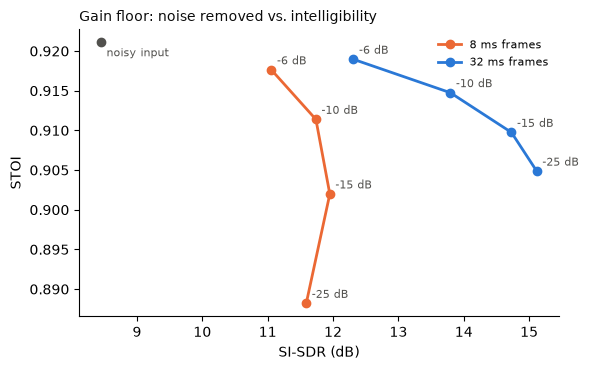

In [9]:
floors = res[(res.rule == "wiener_dd") & (res.noise == "spp") & (res.overlap == 2) & res.frame_ms.isin([8, 32])]
floor_table = floors.groupby(["frame_ms", "floor_db"])[["si_sdr", "stoi", "pesq"]].mean()

fig, ax = plt.subplots(figsize=(6, 3.8))
for ms, color in ((8, ORANGE), (32, BLUE)):
    part = floor_table.loc[ms]
    ax.plot(part.si_sdr, part.stoi, color=color, marker="o", linewidth=2, label=f"{ms} ms frames")
    for floor, row in part.iterrows():
        ax.annotate(f"{floor:.0f} dB", (row.si_sdr, row.stoi), xytext=(4, 4), textcoords="offset points", fontsize=8, color=MUTED)
ax.scatter([noisy.si_sdr.mean()], [noisy.stoi.mean()], color=MUTED, zorder=3)
ax.annotate("noisy input", (noisy.si_sdr.mean(), noisy.stoi.mean()), xytext=(4, -10), textcoords="offset points", fontsize=8, color=MUTED)
ax.set_xlabel("SI-SDR (dB)")
ax.set_ylabel("STOI")
ax.set_title("Gain floor: noise removed vs. intelligibility", fontsize=10, color=TEXT, loc="left")
ax.legend(frameon=False, fontsize=8)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()
floor_table.style.format({"si_sdr": "{:.2f}", "stoi": "{:.3f}", "pesq": "{:.2f}"})

## 5. Where intelligibility is lost: the onset of every word

The decision-directed estimate leans on the previous frame's output, so when a word starts it still
"remembers" the noise-only frames before it and keeps the gain low for a few frames. Longer frames hide
this a little, because their latency is also look-ahead: when an output sample plays, the frame that
produced it has already seen what comes after. The two-step rule (Plapous, Marro and Scalart 2006)
refines the decision-directed gain with the current frame, xi2 = G_dd² · gamma, which removes that delay
for strong onsets while weak noise peaks stay suppressed.

**Measuring what the gain does to the speech alone.** The noise reduction is a time-varying linear
filter whose gains are computed from the noisy signal. Applying *those same gains* to the clean speech
alone shows how much speech they remove at every moment, without the noise in the way. Word onsets are
taken from the clean speech (2 ms blocks, the first active block after at least 50 ms below 30 dB under
the sentence's loud level), and the speech attenuation is averaged across onsets, on 1 of every 4
sentences. 8 ms frames, SPP noise estimate, −15 dB floor.

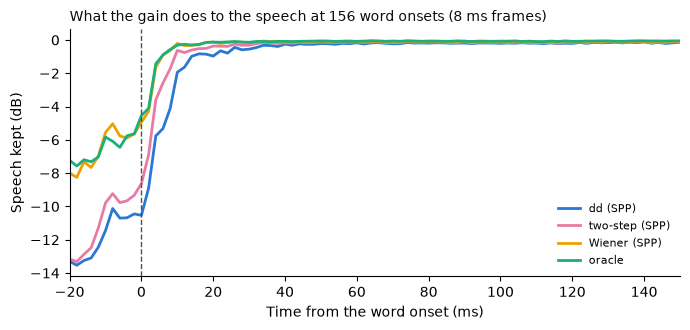

,first 10 ms (dB),all active speech (dB)
dd (SPP),-4.9,-0.6
two-step (SPP),-2.4,-0.5
Wiener (SPP),-1.0,-0.4
oracle,-0.9,-0.2


In [10]:
BLOCK, PRE, POST = 32, 10, 150                    # 2 ms blocks; from 20 ms before to 300 ms after onsets

def gains_of(rule, ms, clean, noisy):
    # The gain of every frame, computed from the noisy signal
    n_fft, hop = frame_sizes(ms, SR)
    if rule == "oracle":
        return list(OracleWiener(clean, noisy - clean, n_fft, hop).gains)
    reducer = NoiseReducer(SPPNoise(n_fft // 2 + 1, hop / SR), hop / SR, rule)
    gains = []
    def fn(X):
        out = reducer(X)
        gains.append(reducer.gain)
        return out
    process_signal(noisy, Wola(n_fft, hop), fn)
    return gains

def apply_gains(gains, x, ms):
    n_fft, hop = frame_sizes(ms, SR)
    it = iter(gains)
    return process_signal(x, Wola(n_fft, hop), lambda X: next(it) * X)

def block_energy(x):
    n = len(x) // BLOCK
    return np.sum(x[:n * BLOCK].reshape(n, BLOCK) ** 2, axis=1)

def word_onsets(clean):
    level = 10 * np.log10(np.convolve(block_energy(clean), np.ones(5) / 5, "same") + 1e-12)
    active = level > np.percentile(level, 95) - 30
    onsets = [k for k in range(25, len(active) - POST)
              if active[k] and not active[k - 25:k].any() and active[k:k + 50].mean() > 0.6]
    return onsets, active

rules = {"dd (SPP)": "wiener_dd", "two-step (SPP)": "wiener_tsnr", "Wiener (SPP)": "wiener", "oracle": "oracle"}
kept = {name: np.zeros(PRE + POST) for name in rules}
total = np.zeros(PRE + POST)
steady = {name: np.zeros(2) for name in rules}
n_onsets = 0
for name in names[::4]:
    speech, mixture = load_pair(name)                 # clean and noisy signals of this sentence
    onsets, active = word_onsets(speech)
    n_onsets += len(onsets)
    e_clean = block_energy(speech)
    for k in onsets:
        total += e_clean[k - PRE:k + POST]
    for method, rule in rules.items():
        e = block_energy(apply_gains(gains_of(rule, 8, speech, mixture), speech, 8))
        for k in onsets:
            kept[method] += e[k - PRE:k + POST]
        steady[method] += [e[active].sum(), e_clean[active].sum()]

t_ms = (np.arange(PRE + POST) - PRE) * BLOCK / SR * 1000
fig, ax = plt.subplots(figsize=(7, 3.4))
for (method, color) in (("dd (SPP)", BLUE), ("two-step (SPP)", PINK), ("Wiener (SPP)", YELLOW), ("oracle", GREEN)):
    ax.plot(t_ms, 10 * np.log10(kept[method] / total), color=color, linewidth=2, label=method)
ax.axvline(0, color=MUTED, linewidth=1, linestyle="--")
ax.set_xlim(-20, 150)
ax.set_xlabel("Time from the word onset (ms)")
ax.set_ylabel("Speech kept (dB)")
ax.set_title(f"What the gain does to the speech at {n_onsets} word onsets (8 ms frames)", fontsize=10, color=TEXT, loc="left")
ax.legend(frameon=False, fontsize=8, loc="lower right")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(FIGURES / "denoising_onsets.png", dpi=150)
plt.show()

first = (t_ms >= 0) & (t_ms < 10)
pd.DataFrame({"first 10 ms (dB)": {m: 10 * np.log10(kept[m][first].sum() / total[first].sum()) for m in rules},
              "all active speech (dB)": {m: 10 * np.log10(steady[m][0] / steady[m][1]) for m in rules}}).style.format("{:+.1f}")

**Does fixing the onsets bring back the intelligibility?** Paired comparison on all 824 sentences
(same sentences, same noise estimate, only the gain rule changes):

In [11]:
pair = main[main.method.isin(["dd (SPP)", "two-step (SPP)"])].pivot_table(
    index=["file", "frame_ms"], columns="method", values=["stoi", "si_sdr"])
rows = []
for ms in FRAMES_MS:
    part = pair.xs(ms, level="frame_ms")
    for metric in ("stoi", "si_sdr"):
        diff = part[(metric, "two-step (SPP)")] - part[(metric, "dd (SPP)")]
        rows.append({"frame (ms)": ms, "metric": metric.upper().replace("_", "-"), "two-step − dd": diff.mean(),
                     "standard error": diff.std() / np.sqrt(len(diff)), "sentences improved": (diff > 0).mean()})
pd.DataFrame(rows).set_index(["frame (ms)", "metric"]).style.format(
    {"two-step − dd": "{:+.4f}", "standard error": "{:.4f}", "sentences improved": "{:.0%}"})

## 6. Quality vs. intelligibility

PESQ (wide-band, ITU-T P.862.2) predicts how listeners would rate the quality of the speech. It was
computed in Colab with the same script ([`denoising_pesq.ipynb`](denoising_pesq.ipynb)), because the
`pesq` package needs a C compiler. The noisy input scores 1.97, the value published for this test set,
which confirms that the processing and the measurement are comparable with the literature (where the
Wiener filter baseline is usually quoted at 2.22, e.g. in Pascual et al., 2017).

Every configuration at 8 ms, a frame that fits a hearing-aid budget, placed by what it does to quality
(PESQ) and to intelligibility (STOI):

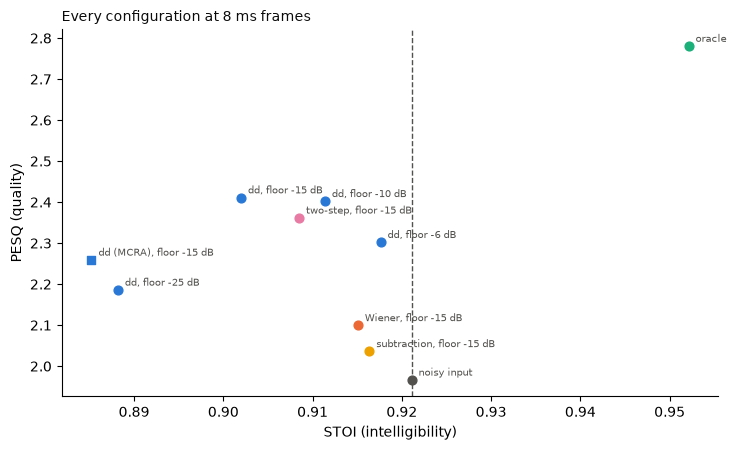

In [12]:
at8 = res[(res.frame_ms == 8) & (res.overlap == 2) & (res.rule != "noisy")].copy()
at8["label"] = [("oracle" if r == "oracle" else f"{label[(r, n, 2)]}, floor {f:.0f} dB")
                for r, n, f in zip(at8.rule, at8.noise, at8.floor_db)]
points = at8.groupby(["label", "rule", "floor_db"])[["stoi", "pesq"]].mean().reset_index()
colors = {"subtraction": YELLOW, "wiener": ORANGE, "wiener_dd": BLUE, "wiener_tsnr": PINK, "oracle": GREEN}

fig, ax = plt.subplots(figsize=(7.5, 4.6))
for _, p in points.iterrows():
    mcra = "MCRA" in p.label
    ax.scatter(p.stoi, p.pesq, s=40, color=colors[p.rule], marker="s" if mcra else "o", zorder=3)
    ax.annotate(p.label.replace(" (SPP)", ""), (p.stoi, p.pesq), xytext=(5, 3), textcoords="offset points",
                fontsize=7.5, color=MUTED)
ax.scatter([noisy.stoi.mean()], [noisy.pesq.mean()], s=40, color=MUTED, zorder=3)
ax.annotate("noisy input", (noisy.stoi.mean(), noisy.pesq.mean()), xytext=(5, 3), textcoords="offset points", fontsize=7.5, color=MUTED)
ax.axvline(noisy.stoi.mean(), color=MUTED, linewidth=1, linestyle="--")
ax.set_xlabel("STOI (intelligibility)")
ax.set_ylabel("PESQ (quality)")
ax.set_title("Every configuration at 8 ms frames", fontsize=10, color=TEXT, loc="left")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(FIGURES / "denoising_quality_intelligibility.png", dpi=150)
plt.show()

## Conclusions

- **The framework is exact and cheap; its latency is the frame length.** WOLA with square-root Hann
  windows reconstructs the input to 10⁻¹⁵, and a frame costs ~50 µs in Python (2.5% of real time with
  4 ms frames). The delay is the frame length N whatever the hop, so the frame length is the axis that
  matters for a hearing aid.
- **Estimating the noise matters as much as the gain rule.** MCRA overestimates the noise (median error
  +1.2 dB with 32 ms frames, +2.9 dB with 4 ms) because it absorbs the onset of every sound before its
  speech detector reacts; the SPP estimator is within 1 dB (−0.3 to −0.9 dB). With the same
  decision-directed Wiener rule, SPP is 2.0 to 3.0 dB better in SI-SDR, and with MCRA and 4 ms frames the
  output is worse than the noisy input (7.2 dB vs. 8.4 dB).
- **The price of latency.** The decision-directed rule with SPP takes SI-SDR from 8.4 dB to 14.7 dB with
  textbook 32 ms frames, 12.0 dB with 8 ms (within a hearing-aid budget) and 10.0 dB with 4 ms. Part of
  the loss is unavoidable for any gain per bin: even the oracle falls from 18.9 to 16.7 and 15.3 dB, because
  short frames cannot resolve the harmonics of the voice. The rest is estimation, and it grows as frames
  shorten: the gap to the oracle is 4.2 dB at 32 ms and 5.3 dB at 4 ms.
- **Cleaner, but not more intelligible.** No real method raises STOI above the noisy input (0.921).
  Spectral subtraction and plain Wiener keep it (0.913–0.922); the decision-directed rule, which removes
  the most noise, lowers it (0.894–0.910), and most at low input SNR (−0.039 below 4 dB with 4 ms
  frames), exactly where help is needed. The oracle gain raises it to 0.946–0.958 (+0.061 at low SNR):
  a gain per bin *can* improve intelligibility, but not with the classical estimate of the a priori SNR.
  This agrees with listening tests of classical single-microphone noise reduction (Hu and Loizou, 2007).
  For a hearing aid, whose purpose is understanding speech, this is the main limitation, and the case
  for a learned estimator of the gain.
- **Part of the loss is at the onset of every word.** Applying the gains to the clean speech alone shows
  that the decision-directed rule removes 4.9 dB of the first 10 ms of each word with 8 ms frames, against
  0.9 dB for the oracle: it leans on the previous, noise-only frame, so the gain rises late, right on
  the short consonants that carry intelligibility (longer frames hide it in part, because their latency
  is also look-ahead). The two-step refinement (Plapous et al., 2006) halves the onset loss
  (2.4 dB) and raises STOI by +0.006 to +0.007 at every frame length, in 92-96% of the sentences, with
  SI-SDR within ±0.5 dB. That recovers about a third of the STOI lost at 8 ms (0.902 → 0.908, against
  0.921 for the input). The rest is not timing, since plain Wiener already treats onsets almost like the
  oracle and still loses STOI; most likely it is the SNR misestimated where the speech is below the
  noise, which the oracle knows and the estimators do not.
- **Quality improves, and 8 ms keeps almost all of it.** PESQ goes from 1.97 for the noisy input (the
  published value for this test set) to 2.41-2.47 with the decision-directed rule at 8 to 32 ms frames:
  an 8 ms frame keeps 92% of the quality gained at 32 ms, while 4 ms keeps only half (2.20). The oracle
  reaches 2.78 at 8 ms and 3.05 at 32 ms. For reference, the Wiener baseline usually quoted on this test
  set scores 2.22.
- **Quality and intelligibility pull in opposite directions.** At 8 ms, the decision-directed rule, which
  suppresses musical noise, has the best PESQ (2.41, against 2.10 for plain Wiener and 2.04 for spectral
  subtraction) and the worst STOI; the two-step rule gives up 0.05 of PESQ for +0.0065 of STOI. The gain
  floor sets the balance: lowering it from −6 to −25 dB with 32 ms frames takes SI-SDR from 12.3 to
  15.1 dB and STOI from 0.919 to 0.905, and with 8 ms frames −25 dB is worse than −15 dB in all three
  metrics (when a bin mixes harmonics and noise, deeper suppression removes speech as much as noise).
  **Among the configurations tested, a −10 dB floor at 8 ms is the best compromise for a hearing aid**:
  the quality of −15 dB (PESQ 2.40 vs. 2.41) with clearly more intelligibility (STOI 0.911 vs. 0.902),
  and 3.3 dB of SI-SDR over the input. This is why hearing aids limit the attenuation.
- **75% overlap** (same latency, twice the frames) changes little: +0.005 STOI with 4 and 8 ms frames,
  SI-SDR within ±0.2 dB.

Still to measure: the latency of the whole chain live, from the microphone to wired headphones
([`scripts/hearing_aid_demo.py`](../scripts/hearing_aid_demo.py)).